<a href="https://colab.research.google.com/github/samanpython098/Myresearch/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print(df.head(10))
print(df.shape)
print(df.columns)
print(iris.target_names)


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
5       0  
6       0  
7       0  
8       0  
9       0 

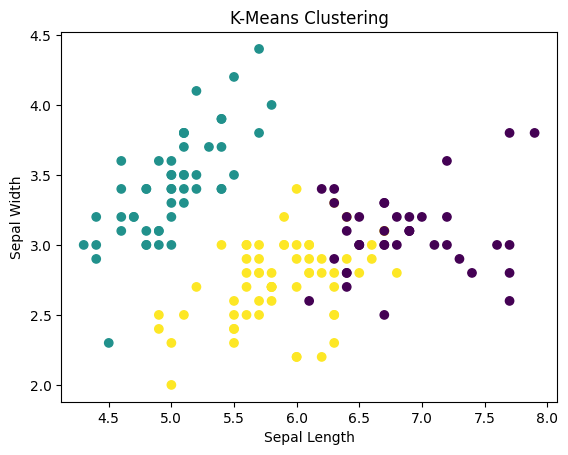

    target  cluster
0        0        1
1        0        1
2        0        1
3        0        1
4        0        1
5        0        1
6        0        1
7        0        1
8        0        1
9        0        1
10       0        1
11       0        1
12       0        1
13       0        1
14       0        1
15       0        1
16       0        1
17       0        1
18       0        1
19       0        1


In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df.iloc[:, :-1])

plt.scatter(df.iloc[:,0], df.iloc[:,1], c=df['cluster'])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clustering')
plt.show()

print(df[['target', 'cluster']].head(20))


In [3]:
from sklearn.metrics import silhouette_score

print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(df.iloc[:, :-2], df['cluster']))


Inertia: 78.85566582597727
Silhouette Score: 0.551191604619592


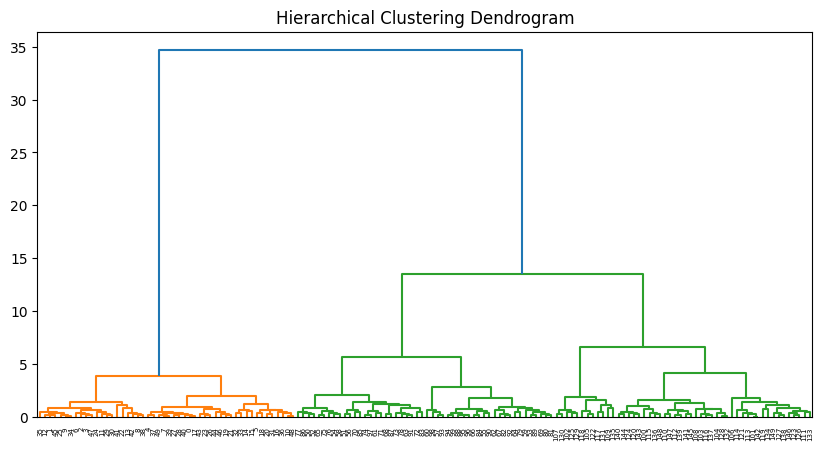

    target  hc_cluster
0        0           1
1        0           1
2        0           1
3        0           1
4        0           1
5        0           1
6        0           1
7        0           1
8        0           1
9        0           1
10       0           1
11       0           1
12       0           1
13       0           1
14       0           1
15       0           1
16       0           1
17       0           1
18       0           1
19       0           1


In [4]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

hc = AgglomerativeClustering(n_clusters=3)
df['hc_cluster'] = hc.fit_predict(df.iloc[:, :-2])

# Dendrogram
linked = linkage(df.iloc[:, :-2], method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

print(df[['target', 'hc_cluster']].head(20))